# Annotated fields: correct, mismatch or missed

For one run and one sample, every field the person annotated is checked against what each
model wrote at the same place:

| Label | You annotated | The model wrote | Meaning |
|---|---|---|---|
| **Correct** | a value | the same value | the model got it right |
| **Mismatch** | a value | a different value | it found the spot but wrote something else |
| **Missed** | a value | nothing, or an empty value | it did not capture the information |

Fields the person left empty are not shown. Two figures follow, both sized for slides and
saved in the run's folder, then a table of every annotated field.

**To look at another run or sample:** change `RUN`, `SAMPLE` and `PROMPT` in the next cell.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

RUN    = "v9-narrative"                           # a folder under data/output/rda/runs/
SAMPLE = 6
PROMPT = "v9"                                    # shown in the figure titles
FOLDER = Path("data/output/rda/runs") / RUN
RESULT = FOLDER / "evaluation_results.xlsx"
# A folder that holds one sample keeps plain figure names; a folder with several samples
# (e.g. v9, samples 1-10) gets the sample number in the names so they do not overwrite each other.
SUFFIX = "" if RUN.endswith(f"-sample{SAMPLE}") else f"_sample{SAMPLE}"
MODELS = ["llama3.1-8b", "gemma4-e4b", "llama3.3-70b"]
NAME   = {"llama3.1-8b": "Llama 3.1 8B", "gemma4-e4b": "Gemma 4 e4b", "llama3.3-70b": "Llama 3.3 70B"}
OUTCOMES = ["Correct", "Mismatch", "Missed"]
COLOUR = {"Correct": "#2a78d6", "Mismatch": "#e34948", "Missed": "#898781"}

INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "text.color": INK})
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 220)


## What the labels mean

Every field of the form falls into one of five cases, depending on whether the person
annotated it and whether the model wrote a value there:

| Label | You annotated | The model wrote | Meaning | In the figures below? |
|---|---|---|---|---|
| **Correct** | a value | the same value | the model got it right | yes |
| **Mismatch** | a value | a different value | it found the spot but wrote something else | yes |
| **Missed** | a value | nothing, or an empty value | it did not capture the information | yes |
| **Both empty** | nothing | nothing | the two agree that there is nothing to fill in | no |
| **Extra** | nothing | a value | the model added something the person did not annotate - possibly a hallucination | no, a next step |

When are two values the same? A free-text value counts when at least three-quarters of the
model's words appear in the annotation; identifiers (DOI, email, URL) must be the same thing,
ignoring `https://` and capitals; dates must be the same day.

**Why the figures show only the first three.** They answer one question: what happened to the
fields the person annotated. For every model each annotated field gets exactly one of the three
labels, so they add up to the number of annotated fields.

**Both empty** is not counted as correct here. The scoring in the evaluation notebook does count
it as correct, which rewards a model for leaving fields empty: on sample 14 with prompt v4,
50 of gemma's 59 "correct" were Both empty.

**Extra** is what the evaluation notebook counts as hallucinated when the reference is empty. It
is not tied to an annotated field, so it needs its own view; that is the next step.


## 1. One outcome per annotated field and model


In [2]:
details = pd.read_excel(RESULT, sheet_name="details")
if "sample" in details:
    details = details[details["sample"] == SAMPLE]
details["model"] = details["model"].str.replace(":", "-")


def outcome(rows):
    """The evaluation writes one or two rows per annotated field; reduce them to one outcome."""
    if (rows.verdict == "Correct").any():
        return "Correct"
    wrote = rows[(rows.verdict == "Hallucinated") & (rows.reason != "empty where the reference has a value")]
    return "Mismatch" if len(wrote) else "Missed"


annotated = details[details["reference value"].notna()]
fields = (annotated.groupby(["field", "model"]).apply(outcome, include_groups=False)
          .rename("outcome").reset_index())
values = annotated.drop_duplicates("field").set_index("field")["reference value"]
wrote = (annotated[annotated["model value"].notna()]
         .drop_duplicates(["field", "model"]).set_index(["field", "model"])["model value"])

models = [m for m in MODELS if m in set(fields.model)]
n_fields = fields.field.nunique()
print(f"run {RUN}, sample {SAMPLE}: {n_fields} annotated fields, models: {', '.join(models)}")
display(fields.pivot_table(index="model", columns="outcome", values="field", aggfunc="count", fill_value=0)
        .reindex(index=models, columns=OUTCOMES, fill_value=0))


run v9-narrative, sample 6: 11 annotated fields, models: llama3.1-8b, gemma4-e4b, llama3.3-70b


outcome,Correct,Mismatch,Missed
model,,,
llama3.1-8b,2,0,9
gemma4-e4b,1,1,9
llama3.3-70b,8,0,3


## 2. The matrix: correct, mismatch and missed

Rows: the annotated fields, grouped into parts of the form, with how many were annotated in
brackets. Columns: for each model, how many of them were correct (blue), a mismatch (red) or
missed (grey), and that share of the row. The darker a cell, the larger its share.
Saved as `matrix_three_labels.png`.


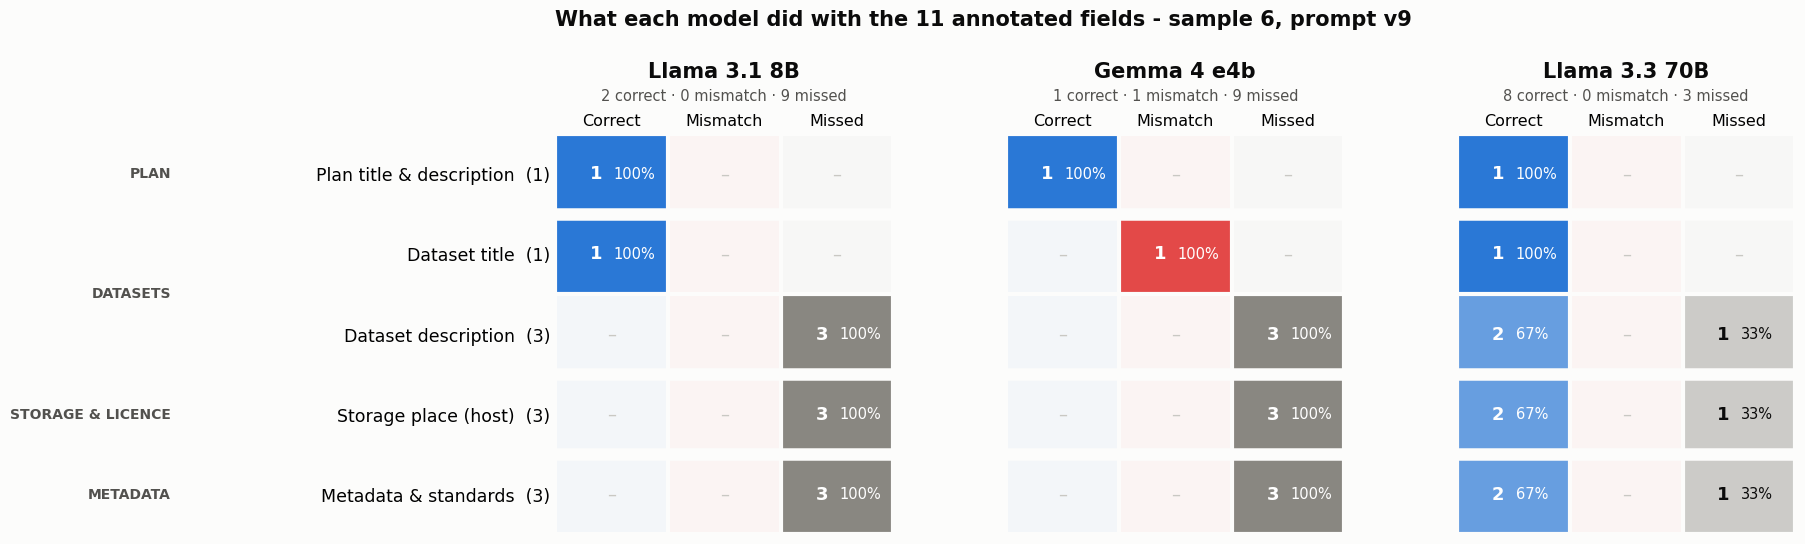

saved -> data\output\rda\runs\v9-narrative\matrix_three_labels_sample6.png


In [3]:
def row_of(path):
    p = re.sub(r"\[\d+\]", "", path).replace("dmp.", "", 1)
    if p in ("title", "description"):                      return "Plan", "Plan title & description"
    if p.startswith("contact"):                            return "Contact", "Contact person"
    if p.startswith("contributor"):                        return "People & project", "Contributors"
    if p.startswith("project"):                            return "People & project", "Project & funding"
    if p.startswith("dataset.distribution.data_access"):   return "Storage & licence", "Data access"
    if p.startswith("dataset.distribution.host"):          return "Storage & licence", "Storage place (host)"
    if p.startswith("dataset.distribution.license"):       return "Storage & licence", "Licence"
    if p.startswith("dataset.distribution"):               return "Storage & licence", "Other distribution details"
    if p.startswith("dataset.metadata"):                   return "Metadata", "Metadata & standards"
    if p == "dataset.title":                               return "Datasets", "Dataset title"
    if p == "dataset.description":                         return "Datasets", "Dataset description"
    if p == "dataset.type":                                return "Datasets", "Dataset type"
    if p in ("dataset.personal_data", "dataset.sensitive_data"):
        return "Datasets", "Personal & sensitive data"
    if p.startswith("dataset"):                            return "Datasets", "Dataset identifier & dates"
    return "Plan", "Plan details (dates, ID, language, ethics)"


ROWS = [("Plan", "Plan title & description"), ("Plan", "Plan details (dates, ID, language, ethics)"),
        ("Contact", "Contact person"),
        ("Datasets", "Dataset title"), ("Datasets", "Dataset description"), ("Datasets", "Dataset type"),
        ("Datasets", "Personal & sensitive data"), ("Datasets", "Dataset identifier & dates"),
        ("Storage & licence", "Storage place (host)"), ("Storage & licence", "Data access"),
        ("Storage & licence", "Licence"), ("Storage & licence", "Other distribution details"),
        ("Metadata", "Metadata & standards"),
        ("People & project", "Contributors"), ("People & project", "Project & funding")]

fields[["section", "row"]] = fields["field"].map(row_of).tolist()
n_row = fields.drop_duplicates("field").groupby(["section", "row"]).size()
rows = [r for r in ROWS if r in n_row.index]
counts = (fields.groupby(["section", "row", "model", "outcome"]).size()
          .unstack(fill_value=0).reindex(columns=OUTCOMES, fill_value=0))

cols = []
for k, m in enumerate(models):
    cols += [(m, o) for o in OUTCOMES] + ([None] if k < len(models) - 1 else [])
surface = np.array(mcolors.to_rgb(SURFACE))


def n_of(r, c):
    return counts.loc[(*r, c[0]), c[1]] if (*r, c[0]) in counts.index else 0


img = np.ones((len(rows), len(cols), 3)) * surface
for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        if c is None:
            continue
        n = n_of(r, c)
        strength = 0.12 + 0.88 * (n / n_row[r]) if n else 0.04
        img[i, j] = surface * (1 - strength) + np.array(mcolors.to_rgb(COLOUR[c[1]])) * strength

fig, ax = plt.subplots(figsize=(16, 0.52 * len(rows) + 2.6))
ax.imshow(img, aspect="auto")
for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        if c is None:
            continue
        n = n_of(r, c)
        share = n / n_row[r]
        if not n:
            ax.text(j, i, "–", ha="center", va="center", fontsize=13, color="#c9c8c3")
            continue
        ink = "white" if share > 0.5 else INK
        ax.text(j - 0.08, i, str(n), ha="right", va="center", fontsize=13, fontweight="bold", color=ink)
        ax.text(j + 0.02, i, f"{share:.0%}", ha="left", va="center", fontsize=10.5, color=ink)

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f"{r[1]}  ({n_row[r]})" for r in rows], fontsize=12.5)
ax.tick_params(length=0)
blocks = [(cols.index((m, OUTCOMES[0])) - 0.5, cols.index((m, OUTCOMES[-1])) + 0.5) for m in models]
for i in range(len(rows) + 1):                                 # the same white gap between every pair of rows
    ax.axhline(i - 0.5, color=SURFACE, linewidth=3, zorder=3)
for j in range(len(cols) + 1):                                 # and between every pair of columns
    ax.axvline(j - 0.5, color=SURFACE, linewidth=3, zorder=3)
for s in dict.fromkeys(r[0] for r in rows):
    idx = [i for i, r in enumerate(rows) if r[0] == s]
    ax.text(-0.31, (idx[0] + idx[-1]) / 2, s.upper(), transform=ax.get_yaxis_transform(), ha="right",
            va="center", fontsize=10, fontweight="bold", color=MUTED)
    if idx[0] > 0:                                             # a wider white gap between sections
        ax.axhline(idx[0] - 0.5, color=SURFACE, linewidth=9, zorder=4)

ax.set_xticks([j for j, c in enumerate(cols) if c])
ax.set_xticklabels([c[1] for c in cols if c], fontsize=11.5)
ax.xaxis.tick_top()
for m in models:
    first = cols.index((m, OUTCOMES[0]))
    t = counts.xs(m, level="model").sum()
    # placed a fixed distance above the grid (in points), so the layout holds for any number of rows
    ax.annotate(NAME.get(m, m), xy=(first + 1, 1), xycoords=("data", "axes fraction"), xytext=(0, 38),
                textcoords="offset points", ha="center", va="bottom", fontsize=15, fontweight="bold")
    ax.annotate(f"{t['Correct']} correct · {t['Mismatch']} mismatch · {t['Missed']} missed",
                xy=(first + 1, 1), xycoords=("data", "axes fraction"), xytext=(0, 22),
                textcoords="offset points", ha="center", va="bottom", fontsize=10.5, color=MUTED)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f"What each model did with the {n_fields} annotated fields - sample {SAMPLE}, prompt {PROMPT}",
             loc="left", fontsize=15, fontweight="bold", pad=78)
out = FOLDER / f"matrix_three_labels{SUFFIX}.png"
fig.savefig(out, dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"saved -> {out}")


## 3. The heatmap: share extracted correctly

One row per model, one column per part of the form, with how many fields were annotated in
brackets. Each cell: the share of that part extracted correctly (also its colour), and how
many of how many. Saved as `slide_option1_heatmap.png`.


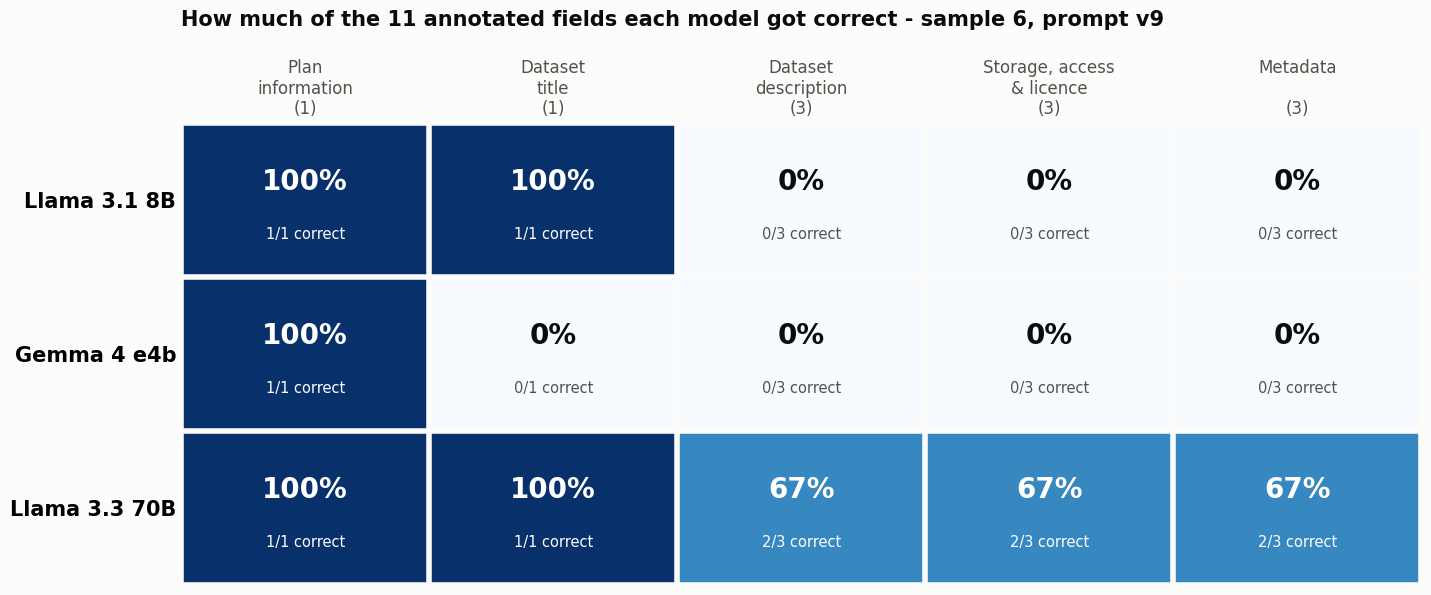

saved -> data\output\rda\runs\v9-narrative\slide_option1_heatmap_sample6.png


In [4]:
def group(path):
    p = re.sub(r"\[\d+\]", "", path)
    if p.startswith("dmp.dataset."):
        rest = p[len("dmp.dataset."):]
        if rest == "title": return "Dataset title"
        if rest == "description": return "Dataset description"
        if rest.startswith("distribution"): return "Storage, access & licence"
        if rest.startswith("metadata"): return "Metadata"
        return "Dataset properties"
    if p.startswith("dmp.contact"): return "Contact"
    if p.startswith("dmp.contributor"): return "Contributors"
    if p.startswith("dmp.project"): return "Project & funding"
    return "Plan information"


GROUPS = ["Plan information", "Contact", "Dataset title", "Dataset description", "Dataset properties",
          "Storage, access & licence", "Metadata", "Contributors", "Project & funding"]
WRAP = {"Plan information": "Plan\ninformation", "Dataset title": "Dataset\ntitle",
        "Dataset description": "Dataset\ndescription", "Dataset properties": "Dataset\nproperties",
        "Storage, access & licence": "Storage, access\n& licence", "Project & funding": "Project &\nfunding",
        "Contact": "Contact\n", "Metadata": "Metadata\n", "Contributors": "Contributors\n"}

fields["group"] = fields.field.map(group)
n_per_group = fields.drop_duplicates("field").group.value_counts()
groups = [g for g in GROUPS if g in n_per_group.index]
cnt = fields.groupby(["model", "group", "outcome"]).size().unstack(fill_value=0).reindex(columns=OUTCOMES, fill_value=0)


def correct(m, g):
    return int(cnt.loc[(m, g), "Correct"]) if (m, g) in cnt.index else 0


fig, ax = plt.subplots(figsize=(16, 6))
pct = np.array([[correct(m, g) / n_per_group[g] for g in groups] for m in models])
ax.imshow(pct, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i, m in enumerate(models):
    for j, g in enumerate(groups):
        v = pct[i, j]
        ax.text(j, i - 0.12, f"{v:.0%}", ha="center", va="center", fontsize=20, fontweight="bold",
                color="white" if v > 0.55 else INK)
        ax.text(j, i + 0.22, f"{correct(m, g)}/{n_per_group[g]} correct", ha="center", va="center", fontsize=10.5,
                color="white" if v > 0.55 else MUTED)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels([f"{WRAP[g]}\n({n_per_group[g]})" for g in groups], fontsize=12, color=MUTED)
ax.xaxis.tick_top()
ax.set_yticks(range(len(models)))
ax.set_yticklabels([NAME.get(m, m) for m in models], fontsize=15, fontweight="bold")
ax.set_xticks(np.arange(-.5, len(groups), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(models), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=4)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f"How much of the {n_fields} annotated fields each model got correct - sample {SAMPLE}, prompt {PROMPT}",
             pad=70, loc="left", fontsize=15, fontweight="bold")
out = FOLDER / f"slide_option1_heatmap{SUFFIX}.png"
fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"saved -> {out}")


## 4. Every annotated field

One row per field the person annotated: the annotated value, each model's outcome, and,
for a mismatch, what the model wrote instead.


In [5]:
wide = fields.pivot(index="field", columns="model", values="outcome").reindex(columns=models)
wide.insert(0, "annotated value", values.reindex(wide.index).astype(str).str.slice(0, 60))
for m in models:
    wide[f"{m} wrote"] = [str(wrote.get((f, m), ""))[:45] if wide.loc[f, m] == "Mismatch" else ""
                          for f in wide.index]
natural = lambda f: [int(x) if x.isdigit() else x for x in re.split(r"(\d+)", f)]
display(wide.loc[sorted(wide.index, key=natural)].reset_index())


model,field,annotated value,llama3.1-8b,gemma4-e4b,llama3.3-70b,llama3.1-8b wrote,gemma4-e4b wrote,llama3.3-70b wrote
0,dmp.dataset[0].description,The bulk of the data generated in this project will be 1...,Missed,Missed,Correct,,,
1,dmp.dataset[0].distribution[0].host.title,group's mass storage system,Missed,Missed,Correct,,,
2,dmp.dataset[0].metadata[0].description,"""Readme"" files will also be provided for explanation of ...",Missed,Missed,Correct,,,
3,dmp.dataset[1].description,Images and video files will be created from the fluid da...,Missed,Missed,Correct,,,
4,dmp.dataset[1].distribution[0].host.title,group's mass storage system,Missed,Missed,Correct,,,
5,dmp.dataset[1].metadata[0].description,"""Readme"" files will also be provided for explanation of ...",Missed,Missed,Correct,,,
6,dmp.dataset[1].title,Images and video files,Correct,Mismatch,Correct,,codes,
7,dmp.dataset[2].description,"Although open-source, we envisage that intellectual righ...",Missed,Missed,Missed,,,
8,dmp.dataset[2].distribution[0].host.title,group's mass storage system,Missed,Missed,Missed,,,
9,dmp.dataset[2].metadata[0].description,"""Readme"" files will also be provided for explanation of ...",Missed,Missed,Missed,,,
